# Introduction to DL

## Perceptron

In [159]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Setosa

per_clf = Perceptron()
per_clf.fit(X, y)

X_new = [[1.5, 0.5], [1.4, 1.9]]
print(per_clf.predict(X_new))

[ True False]


## Regression MLP

In [160]:
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

housing = fetch_california_housing(as_frame=True)
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], max_iter=500)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)

print(f"RMSE: {root_mean_squared_error(y_valid, y_pred)}")

RMSE: 0.5371493125341134


## Classification MLP

In [161]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

mlp_clf = MLPClassifier(hidden_layer_sizes=[10], max_iter=500)
mlp_clf.fit(X_train, y_train)

y_pred = mlp_clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.88


c:\Users\Yehor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# MLPs via Keras

In [162]:
import keras
import tensorflow as tf
import numpy as np

fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000] # cutting of 5000 indexes from end
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:] # taking cutted of 5000 indexes from end

print(X_train.shape)
print(X_train.dtype)

X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test_full / 255.

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Labels: {[(i, label) for i, label in zip(range(len(class_names)), class_names)]}")

(55000, 28, 28)
uint8
Labels: [(0, 'T-shirt/top'), (1, 'Trouser'), (2, 'Pullover'), (3, 'Dress'), (4, 'Coat'), (5, 'Sandal'), (6, 'Shirt'), (7, 'Sneaker'), (8, 'Bag'), (9, 'Ankle boot')]


In [163]:
keras.backend.clear_session()

model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))

# --- or ---

model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(), # converts 28x28 matrix to a flattene array-vector of shape 7845
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [164]:
print(model.get_layer("dense_2") is model.layers[1])

dense_layer_2 = model.get_layer("dense_3")
print(f"Layer parameters (weights): {dense_layer_2.get_weights()[0]}") # get_weights() -> (weights, biases)
print(f"Weights shape: {dense_layer_2.get_weights()[0].shape}")

True
Layer parameters (weights): [[-0.04723686  0.04672769  0.01857799 ...  0.1005765   0.10237766
   0.11932375]
 [ 0.04117983 -0.1132585  -0.01261285 ... -0.10596402 -0.09906329
  -0.09922015]
 [-0.02892603 -0.00400376 -0.00719481 ... -0.02732034  0.01106278
  -0.03394043]
 ...
 [ 0.06255359 -0.01373209  0.05817633 ...  0.00711539  0.04940953
   0.08386541]
 [ 0.03947594  0.08507823  0.10985697 ...  0.01514515  0.09286945
  -0.01312806]
 [ 0.0776987  -0.01096041  0.10740467 ...  0.10228413  0.0273072
  -0.12225566]]
Weights shape: (300, 100)


In [165]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
fashion_mnist = model = model

In [166]:
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)

Epoch 1/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7501 - loss: 0.7602 - val_accuracy: 0.8149 - val_loss: 0.5476
Epoch 2/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step - accuracy: 0.8257 - loss: 0.5064 - val_accuracy: 0.8334 - val_loss: 0.4810
Epoch 3/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 989us/step - accuracy: 0.8411 - loss: 0.4551 - val_accuracy: 0.8448 - val_loss: 0.4494
Epoch 4/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step - accuracy: 0.8507 - loss: 0.4274 - val_accuracy: 0.8464 - val_loss: 0.4435
Epoch 5/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 979us/step - accuracy: 0.8569 - loss: 0.4070 - val_accuracy: 0.8537 - val_loss: 0.4297
Epoch 6/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 986us/step - accuracy: 0.8641 - loss: 0.3907 - val_accuracy: 0.8625 - val_loss: 0.4048
Epoch 7/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 995us/step - accuracy: 0.8667 - loss: 0.3774 - val_accuracy: 0.8614 - val_loss: 0.4065
Epoch 8/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 980us/step - accuracy: 0.8720 - l

['accuracy', 'loss', 'val_accuracy', 'val_loss']


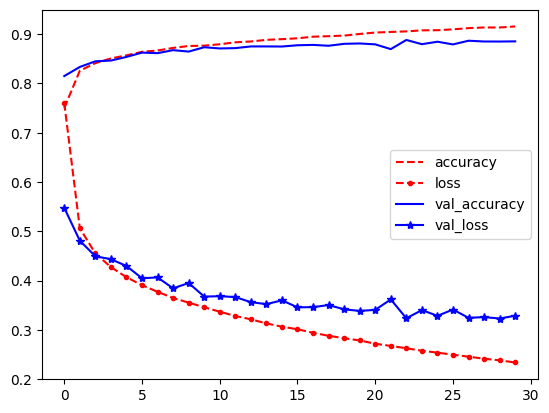

In [167]:
import matplotlib.pyplot as plt
import pandas as pd

print(list(history.history))
pd.DataFrame(history.history).plot(
    style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

In [168]:
model.evaluate(X_valid, y_valid)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 716us/step - accuracy: 0.8796 - loss: 0.3322


[0.33224058151245117, 0.8795999884605408]

In [169]:
X_new = X_valid[:3]
y_pred = np.argmax(model.predict(X_new), axis=-1)

print(f"Predictions: {np.array(class_names)[y_pred]}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predictions: ['Shirt' 'Bag' 'T-shirt/top']


# Wide & Deep DNN (Functional API)

In [170]:
normalization_layer = keras.layers.Normalization() # same as sklearn's StandarScaler
hidden_layer_1 = keras.layers.Dense(30, activation="relu")
hidden_layer_2 = keras.layers.Dense(30, activation="relu")
concatenate_layer = keras.layers.Concatenate()
output_layer = keras.layers.Dense(1)

input_ = keras.layers.Input(shape=X_train.shape[1:]) # skip dataset size in shape [!55000!, 28, 28]
normalized = normalization_layer(input_)
hidden_1 = hidden_layer_1(normalized)
hidden_2 = hidden_layer_2(hidden_1)
concat = concatenate_layer([hidden_2, normalized])
output = output_layer(concat)

model = keras.Model(inputs=[input_], outputs=[output])

# Subclass API

In [171]:
class WideAndDeepModel(keras.Model):
    def __init__(self, units: int = 30, activation="relu", **kwargs):
        super().__init__(**kwargs)

        self.norm_layer_wide = keras.layers.Normalization()
        self.nowrm_layer_deep = keras.layers.Normalization()
        self.hidden1 = keras.layers.Dense(units=units, activation=activation)
        self.hidden1 = keras.layers.Dense(units=units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(12)

    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)

        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)

        concatenate = keras.layers.concatenate([hidden2, norm_wide])

        main_output = self.main_output(concatenate)
        aux_output = self.aux_output(hidden2)

        return main_output, aux_output

wide_deep_model = WideAndDeepModel(30, activation="relu", name="wide_and_deep_model")


# Export

In [172]:
import shutil
import os

shutil.rmtree("./export-example", ignore_errors=True) # forcefuly remove not empty directory
os.mkdir("./export-example")

fashion_mnist.save("./export-example/fashion_mnist_model.keras") # zip file
fashion_mnist.save_weights("./export-example/fasion_mnist_model.weights.h5") # .weights.h5 extension

In [173]:
saved_model = keras.models.load_model("./export-example/fashion_mnist_model.keras")
saved_model.load_weights("./export-example/fasion_mnist_model.weights.h5") # only for example, save() saved the model including learned parameters

## Custom Objects Export

In [174]:
wide_deep_model.save("./export-example/wide_and_deep.keras")
saved_wide_deep = keras.models.load_model("./export-example/wide_and_deep.keras", custom_objects={"WideAndDeepModel": WideAndDeepModel}) # include custom objects that model is using e.g. external: functions, classes, variables

c:\Users\Yehor\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_api.py:108: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


# Callbacks

In [175]:
shutil.rmtree("./example", ignore_errors=True)

checkpoint_cb = keras.callbacks.ModelCheckpoint("example/my-checkpoints.weights.h5", save_weights_only=True, save_best_only=True) # save_weights_only=False -> path ends with .keras
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

class CustomCallback(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()

    def set_model(self, model):
        super().set_model(model)

    def set_params(self, params):
        super().set_params(params)

    def on_train_begin(self, logs=None):
        pass

    def on_train_end(self, logs=None):
        pass

    def on_epoch_begin(self, epoch, logs=None):
        pass

    def on_epoch_end(self, epoch, logs=None):
        pass

    def on_train_batch_begin(self, batch, logs=None):
        pass

    def on_train_batch_end(self, batch, logs=None):
        pass

    def on_test_begin(self, logs=None):
        pass

    def on_test_end(self, logs=None):
        pass

    def on_test_batch_begin(self, batch, logs=None):
        pass

    def on_test_batch_end(self, batch, logs=None):
        pass

    def on_predict_begin(self, logs=None):
        pass

    def on_predict_end(self, logs=None):
        pass

    def on_predict_batch_begin(self, batch, logs=None):
        pass

    def on_predict_batch_end(self, batch, logs=None):
        pass

# history = fashion_mnist.fit([...], callbacks=[checkpoint_cb])


# Tensorboard

In [176]:
from pathlib import Path
from time import strftime

def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime(r"run_%Y_%m_%d_%H_%M_%S")

run_logdir = get_run_logdir()
str(run_logdir)

'my_logs\\run_2026_08_24_15_17_45'

In [177]:
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir(), profile_batch=(100, 200))

fashion_mnist_new = keras.models.clone_model(fashion_mnist)
history = fashion_mnist_new.fit(X_train, y_train, callbacks=[tensorboard_cb], epochs=50)

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7662 - loss: 0.7208
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8311 - loss: 0.4873
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8464 - loss: 0.4433
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8561 - loss: 0.4141
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8620 - loss: 0.3932
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8689 - loss: 0.3772
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8716 - loss: 0.3640
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8755 - loss: 0.3522
Epoch 9/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8793 - loss: 0.3413
Epoch 10/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8840 - loss: 0.3310
Epoch 11/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8852 - loss: 0.3230
Epoch 12/50
1719/1719 ━━━━━━━━

In [178]:
tensorboard_cb = keras.callbacks.TensorBoard(get_run_logdir(), profile_batch=(100, 200))


fashion_mnist_new = keras.models.clone_model(fashion_mnist)
fashion_mnist_new.optimizer = keras.optimizers.SGD(learning_rate=0.001)
history = fashion_mnist_new.fit(X_train, y_train, callbacks=[tensorboard_cb], epochs=50)

Epoch 1/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5792 - loss: 1.4550
Epoch 2/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7203 - loss: 0.8596
Epoch 3/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7652 - loss: 0.7201
Epoch 4/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7889 - loss: 0.6501
Epoch 5/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8030 - loss: 0.6043
Epoch 6/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8107 - loss: 0.5721
Epoch 7/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8187 - loss: 0.5475
Epoch 8/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8224 - loss: 0.5286
Epoch 9/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8266 - loss: 0.5133
Epoch 10/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8289 - loss: 0.5009
Epoch 11/50
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8325 - loss: 0.4901
Epoch 12/50
1719/1719 ━━━━━━━━

In [179]:
%load_ext tensorboard
%tensorboard --logdir=./my_logs --port=6008 # access http://127.0.0.1:6008

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6008 (pid 40436), started 7 days, 1:11:44 ago. (Use '!kill 40436' to kill it.)

# Fine-tunning Hyperparameters

In [180]:
import keras_tuner as kt

def build_model(hp: kt.HyperParameters):
    n_hidden = hp.Int(name="n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int(name="n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float(name="learning_rate", min_value=1e-4, max_value=1e-2) # 1e-4 = 1 * 10^-4

    optimizer = hp.Choice(name="optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model = keras.Sequential()
    model.add(keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons))
    model.add(keras.layers.Dense(10, activation="softmax"))
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model

In [181]:
random_search_tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    overwrite=True,
    directory="my_fashion_mnist",
    project_name="my_rnd_research"
)
random_search_tuner.search(X_train, y_train, epochs=3, validation_data=(X_valid, y_valid))

Trial 5 Complete [00h 00m 05s]
val_accuracy: 0.8378000259399414

Best val_accuracy So Far: 0.8378000259399414
Total elapsed time: 00h 00m 31s


In [182]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[0]

In [183]:
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[0].values # best hyperparameters found

{'n_hidden': 3,
 'n_neurons': 132,
 'learning_rate': 0.0037691868045310523,
 'optimizer': 'sgd'}

In [184]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 4 summary
Hyperparameters:
n_hidden: 3
n_neurons: 132
learning_rate: 0.0037691868045310523
optimizer: sgd
Score: 0.8378000259399414


In [185]:
best_trial.metrics.get_last_value("val_accuracy")

np.float64(0.8378000259399414)

In [186]:
best_model.fit(X_train_full, y_train_full, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - accuracy: 0.1004 - loss: nan
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.1000 - loss: nan
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - accuracy: 0.1000 - loss: nan
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - accuracy: 0.1000 - loss: nan
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 716us/step - accuracy: 0.1000 - loss: nan
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - accuracy: 0.1000 - loss: nan
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 714us/step - accuracy: 0.1000 - loss: nan
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step - accuracy: 0.1000 - loss: nan
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 715us/step - accuracy: 0.1000 - loss: nan
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 713us/step - accuracy: 0.1000 - loss: nan


In [187]:
test_loss, test_accuracy = best_model.evaluate(X_valid, y_valid)
print(f"Test loss: {test_loss} \nTest accuracy: {test_accuracy}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 628us/step - accuracy: 0.1042 - loss: nan
Test loss: nan 
Test accuracy: 0.10419999808073044


# Exercises

1. The TensorFlow playground is a handy neural network simulator built by the
TensorFlow team. In this exercise, you will train several binary classifiers in just
a few clicks, and tweak the model's architecture and its hyperparameters to gain
some intuition on how neural networks work and what their hyperparameters
do. Take some time to explore the following:

    a. The patterns learned by a neural net. Try training the default neural network
    by clicking the Run button (top left). Notice how it quickly finds a good
    solution for the classification task. The neurons in the first hidden layer have
    learned simple patterns, while the neurons in the second hidden layer have
    learned to combine the simple patterns of the first hidden layer into more
    complex patterns. In general, the more layers there are, the more complex the
    patterns can be.

    b. Activation functions. Try replacing the tanh activation function with a ReLU
    activation function, and train the network again. Notice that it finds a solution
    even faster, but this time the boundaries are linear. This is due to the shape of
    the ReLU function.

    c. The risk of local minima. Modify the network architecture to have just one
    hidden layer with three neurons. Train it multiple times (to reset the network

    d. What happens when neural nets are too small? Remove one neuron to keep
    just two. Notice that the neural network is now incapable of finding a good
    solution, even if you try multiple times. The model has too few parameters
    and systematically underfits the training set.

    e. What happens when neural nets are large enough? Set the number of neurons
    to eight, and train the network several times. Notice that it is now
    consistently fast and never gets stuck. This highlights an important finding
    in neural network theory: large neural networks rarely get stuck in local minima,
    and even when they do, these local optima are often almost as good as the global
    optimum. However, they can still get stuck on long plateaus for a long time.

    f. The risk of vanishing gradients in deep networks. Select the spiral dataset
    (the bottom-right dataset under "DATA"), and change the network architecture to
    have four hidden layers with eight neurons each. Notice that training takes
    much longer and often gets stuck on plateaus for long periods of time. Also
    notice that the neurons in the highest layers (on the right) tend to evolve
    faster than the neurons in the lowest layers (on the left). This problem, called
    the vanishing gradients problem, can be alleviated with better weight
    initialization and other techniques, better optimizers (such as AdaGrad or Adam),
    or batch normalization (discussed in Chapter 11).

    g. Go further. Take an hour or so to play around with other parameters and
    get a feel for what they do, to build an intuitive understanding about neural
    networks.

2. Draw an ANN using the original artificial neurons (like the ones in Figure 10-3)
that computes $A \oplus B$ (where $\oplus$ represents the XOR operation).
Hint: $A \oplus B = (A \land \neg B) \lor (\neg A \land B)$.

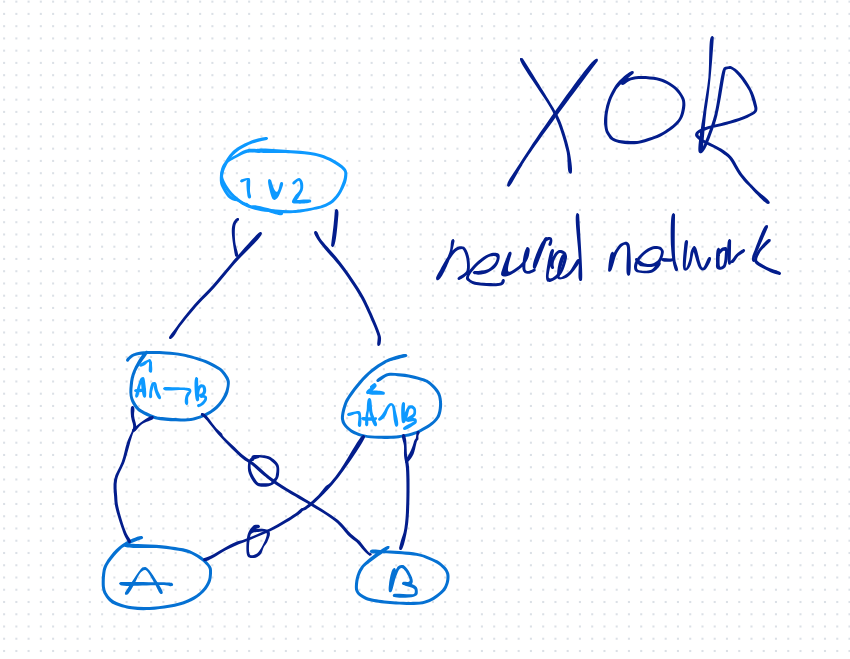

3. Why is it generally preferable to use a logistic regression classifier rather
than a classic perceptron (i.e., a single layer of threshold logic units trained
using the perceptron training algorithm)? How can you tweak a perceptron to make
it equivalent to a logistic regression classifier?

> Because logistic regression designed to return predictions with probabilities. When perceptron is designed as part of the neural net and therefore returns only boolean values. To make perceptron identical to logistic regression, you can change activation function from heaviside or sign to sigmoid.

4. Why was the sigmoid activation function a key ingredient in training the first
MLPs?

> Because after discovery that gradient descent can be used to train MLPs, researchers discovered that the first step(x) function wasn't differetiable at all - so they switched to sigmoid.

5. Name three popular activation functions. Can you draw them?

> tanh, ReLU, sigmoid, linear, heaviside

6. Suppose you have an MLP composed of one input layer with 10 passthrough
neurons, followed by one hidden layer with 50 artificial neurons, and finally
one output layer with 3 artificial neurons. All artificial neurons use the ReLU
activation function.

    a. What is the shape of the input matrix $X$?

    > $X:(10, n)$

    b. What are the shapes of the hidden layer's weight matrix $W_h$ and bias vector $b_h$?

    > $W:(50, 10) \space b:(1, 3)$

    c. What are the shapes of the output layer's weight matrix $W_o$ and bias vector $b_o$?

    > $w:(50, 3) \space b:(1, 3)$

    d. What is the shape of the network's output matrix $Y$?7

    > $y:(3, n)$

    e. Write the equation that computes the network's output matrix $Y$ as a function
    of $X$, $W_h$, $b_h$, $W_o$, and $b_o$.

    >$y=ReLU(ReLU(XW_h^T + b_h)W_o^T + b_o)$

    > Note: used mathematical shapes noting convention

7. How many neurons do you need in the output layer if you want to classify email
into spam or ham? What activation function should you use in the output layer?
If instead you want to tackle MNIST, how many neurons do you need in the output
layer, and which activation function should you use? What about for getting your
network to predict housing prices, as in Chapter 2?

> 1. One output neuron
2. sigmoid(x)
3. Ten output neurons for MNIST
4. softmax(x)
5. One output neuron with no or ReLU activation function   

8. What is backpropagation and how does it work? What is the difference between
backpropagation and reverse-mode autodiff?

> Backpropagation is a training algorithm for neural nets. Basically, it firstly goes through the NN to make predictions and cache predictions for each neuron. Then it uses autodiff technique to calculate gradient for each neuron. Important that is uses previously computed error for previous layers and previous neuron output as cached in the first step constant. 

9. Can you list all the hyperparameters you can tweak in a basic MLP? If the MLP
overfits the training data, how could you tweak these hyperparameters to try to
solve the problem?

> Learning rate, batch size, n hidden layers & n neurons for a layer, regularization (l1, l2), epochs (important to set higher value and use early stopping), optimizer.
First of all I would use early stopping. It would basically regularize powerfull model for better fitting my task. Other ways are review n_neurons and n_layers, for example, if dataset looks like 2 means and they are linearly separable, we only need 1 neuron at all model. Or decrease learning rate.

10. Train a deep MLP on the MNIST dataset (you can load it using
tf.keras.datasets.mnist.load_data()). See if you can get over 98% accuracy by
manually tuning the hyperparameters. Try searching for the optimal learning rate
by using the approach presented in this chapter (i.e., by growing the learning rate
exponentially, plotting the loss, and finding the point where the loss shoots up).
Next, try tuning the hyperparameters using Keras Tuner with all the bells and
whistles—save checkpoints, use early stopping, and plot learning curves using
TensorBoard.


In [201]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

for name, array in {
    "X_train": X_train,
    "y_train": y_train,
    "X_test": X_test,
    "y_test": y_test,
}.items():
    print(f"{name}.shape: {array.shape}")

X_train.shape: (60000, 28, 28)
y_train.shape: (60000,)
X_test.shape: (10000, 28, 28)
y_test.shape: (10000,)


In [202]:
mnist_shape = X_train.shape[1:]

In [245]:
input_ = keras.layers.Input(shape=mnist_shape, name="input")
norm = keras.layers.Normalization()
flatten = keras.layers.Flatten()
hidden_1 = keras.layers.Dense(200, activation="relu")
hidden_2 = keras.layers.Dense(200, activation="relu")
hidden_3 = keras.layers.Dense(100, activation="relu")
output = keras.layers.Dense(10, activation="softmax")

norm.adapt(X_train)
norm_layer = norm(input_)

flatten_layer = flatten(norm_layer)

hidden_layer_1 = hidden_1(flatten_layer)
hidden_layer_2 = hidden_2(hidden_layer_1)
hidden_layer_3 = hidden_3(hidden_layer_2)

output_layer = output(hidden_layer_3)

lr = 1e-5

mnist_model_lr = keras.models.Model(inputs=[input_], outputs=[output_layer], name="mnist_model_for_lr")
mnist_model_lr.compile(optimizer=keras.optimizers.SGD(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [246]:
class LearningRateCallback(keras.callbacks.Callback):
    def __init__(self, base_lr: int | float,  factor: float | int):
        super().__init__()

        self._factor = factor
        self._base_lr = base_lr
        self.lrates = []
        self.losses = []

    def on_train_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self._factor

        if lr == np.float32("inf"):
            self.model.stop_training = True
            self.model.optimizer.learning_rate = self._base_lr

            self.lrates = []
            self.losses = []

        self.model.optimizer.learning_rate = lr
        self.lrates.append(lr)
        self.losses.append(logs.get("loss"))

lr_callback = LearningRateCallback(base_lr=lr, factor=1.01)

In [247]:
history = mnist_model_lr.fit(X_train, y_train, epochs=1, validation_data=(X_test, y_test), callbacks=[lr_callback])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.3185 - loss: nan - val_accuracy: 0.0980 - val_loss: nan


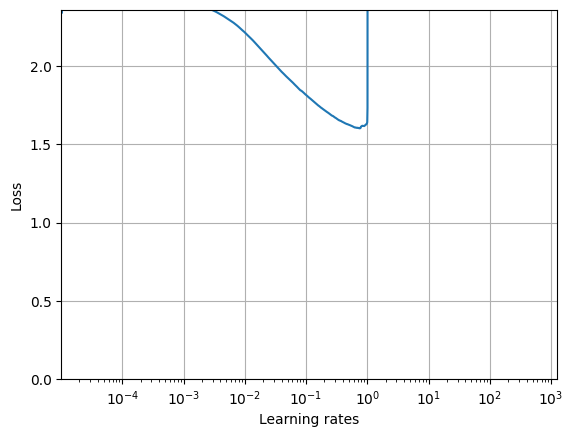

In [248]:
plt.plot(lr_callback.lrates, lr_callback.losses)
plt.gca().set_xscale("log")
plt.axis((min(lr_callback.lrates), max(lr_callback.lrates), 0, lr_callback.losses[0]))

plt.grid()
plt.xlabel("Learning rates")
plt.ylabel("Loss")
plt.show()

In [299]:
keras.backend.clear_session()

input_ = keras.layers.Input(shape=mnist_shape, name="input")
norm = keras.layers.Normalization()
flatten = keras.layers.Flatten()
hidden_1 = keras.layers.Dense(200, activation="relu")
hidden_2 = keras.layers.Dense(200, activation="relu")
hidden_3 = keras.layers.Dense(100, activation="relu")
output = keras.layers.Dense(10, activation="softmax")

norm.adapt(X_train)
norm_layer = norm(input_)

flatten_layer = flatten(norm_layer)

hidden_layer_1 = hidden_1(flatten_layer)
hidden_layer_2 = hidden_2(hidden_layer_1)
hidden_layer_3 = hidden_3(hidden_layer_2)

output_layer = output(hidden_layer_3)

mnist_model = keras.models.Model(inputs=[input_], outputs=[output_layer], name="mnist_model")
mnist_model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

checkpoint_cb = keras.callbacks.ModelCheckpoint("best_mnist_model.keras", save_best_only=True)

tb_path = Path() / "mnist_tensorboard" / strftime(r"run_%Y_%m_%d_%H_%M_%S")
tensorboard_cb = keras.callbacks.TensorBoard(log_dir=tb_path)

In [300]:
history = mnist_model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=[keras.callbacks.EarlyStopping(patience=30), checkpoint_cb, tensorboard_cb])

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9328 - loss: 0.2331 - val_accuracy: 0.9606 - val_loss: 0.1358
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9702 - loss: 0.1031 - val_accuracy: 0.9708 - val_loss: 0.1058
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9804 - loss: 0.0635 - val_accuracy: 0.9718 - val_loss: 0.1102
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9857 - loss: 0.0501 - val_accuracy: 0.9730 - val_loss: 0.1010
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9889 - loss: 0.0380 - val_accuracy: 0.9717 - val_loss: 0.1089
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9925 - loss: 0.0236 - val_accuracy: 0.9732 - val_loss: 0.1168
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9943 - loss: 0.0211 - val_accuracy: 0.9737 - val_loss: 0.1238
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9952 - loss: 0

['accuracy', 'loss', 'val_accuracy', 'val_loss']


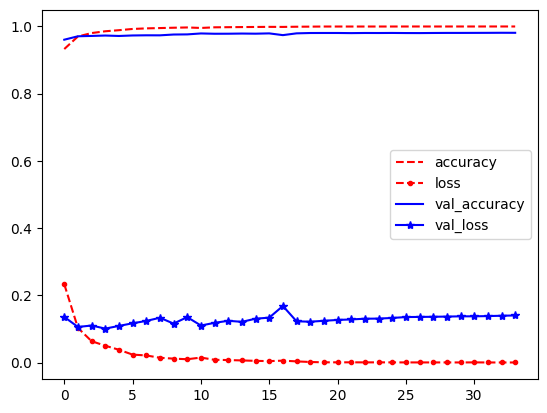

In [301]:
print(list(history.history))
pd.DataFrame(history.history).plot(
    style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

In [303]:
best_saved_model = keras.models.load_model("best_mnist_model.keras")
best_saved_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step - accuracy: 0.9730 - loss: 0.1010


[0.10095993429422379, 0.9729999899864197]

In [306]:
%load_ext tensorboard
%tensorboard --logdir=./mnist_tensorboard --port=6008 # access http://127.0.0.1:6008

%reload_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
